In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# STEP 1: LOAD DATA AND ENFORCE TARGET BOUNDARIES
# ==============================================================================
# Direct workspace string path matching your local environment copy
file_path = "/content/ADNI-DIAN_Comparison_Study_Data_Subset_05_23_22_14Jun2026.csv"
print(f"\U0001f503 Loading Alzheimer's Cohort Matrix: '{file_path}'...")
df = pd.read_csv(file_path, low_memory=False)

# Clean target variable: Strip whitespaces and force text string uniformity
df['ADGROUP_CLEAN'] = df['ADGROUP'].astype(str).str.strip()

print("\n\U0001f4cb Baseline ADGROUP distribution found in raw file:")
print(df['ADGROUP_CLEAN'].value_counts(dropna=False).head(5))

# Filter rows to focus on a crisp, binary diagnosis target boundary
# We isolate Cognitively Normal Baselines from Symptomatic/Impaired Profiles
# Based on the output of df['ADGROUP_CLEAN'].value_counts(), the values are '0.0' and '1.0'
valid_targets = ["0.0", "1.0"]
df_filtered = df[df['ADGROUP_CLEAN'].isin(valid_targets)].copy()

# Map Target: 0 = Healthy Control (Baseline), 1 = Cognitive Impairment Spectrum
df_filtered['TARGET_DIAGNOSIS'] = np.where(
    df_filtered['ADGROUP_CLEAN'] == "0.0", 0, 1
)

# ==============================================================================
# STEP 2: FEATURE SELECTION (STRICT CLINICAL NOTES & COGNITIVE EXAMS ONLY)
# ==============================================================================
# User-provided specific features
# Removed: DIGIF, DIGIFLEN, DIGIB, DIGIBLEN, VEG, WAIS, HXHYPER, HXSTROKE, HACHIN due to >70% missing values
user_features = [
    'EDUC', 'BIRTHMO', 'BIRTHYR', 'HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'GENDER',
    'MOMDEM', 'MOMAUTO', 'DADDEM', 'DADAUTO',
    'WORDIM', 'WORDDEL', 'LOGIMEM', 'MEMUNITS',
    'ANIMALS', 'BOSTON',
    'TRAILA', 'TRAILB', 'FLUF',
    'GDS'
]

# Retain only the defined features that exist directly as columns in your CSV file
valid_features = [col for col in user_features if col in df_filtered.columns]

X = df_filtered[valid_features].copy()
y = df_filtered['TARGET_DIAGNOSIS'].astype(int).values

# ==============================================================================
# STEP 3: CATEGORICAL ENCODING FOR SCIKIT-LEARN PROCESSING
# ==============================================================================
# Map object columns to dummy indicators since Random Forest cannot interpret raw strings
categorical_cols_to_encode = ['HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'GENDER', 'MOMDEM', 'MOMAUTO', 'DADDEM', 'DADAUTO']
actual_categorical_cols = [col for col in categorical_cols_to_encode if col in X.columns]
X = pd.get_dummies(X, columns=actual_categorical_cols, drop_first=True)

# Update features array reference to reflect newly created dummy column names
final_features = list(X.columns)

print(f"\n\u2705 Pure Clinical Matrix Structured: {X.shape[0]} patients with {X.shape[1]} textual/cognitive features.")
print(f"\u2696\ufe0f Class Balance -> Baseline Controls (0): {np.sum(y == 0)} | Impaired Spectrum (1): {np.sum(y == 1)}")

print("\nList of attributes (final_features):")
for feature in final_features:
    print(f"- {feature}")

# ==============================================================================
# STEP 4: STRATIFIED K-FOLD VALIDATION LOOP WITH IMPOUTATION
# ==============================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy, cv_precision, cv_recall, cv_f1, cv_auc = [], [], [], [], []
feature_importances = np.zeros(len(final_features))

# Store results for each fold for later plotting
all_y_val = []
all_preds = []
all_probs = []

print("\n\U0001f680 Initializing Random Forest Cross-Validation Loop...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # IMPOUTATION PHASE: Fill missing entries with column medians to avoid dropping patient rows
    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp = imputer.transform(X_val)

    # Configure classic ensemble trees architecture
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_imp, y_train)

    # Generate test metrics
    preds = model.predict(X_val_imp)
    probs = model.predict_proba(X_val_imp)[:, 1]

    cv_accuracy.append(accuracy_score(y_val, preds))
    cv_precision.append(precision_score(y_val, preds))
    cv_recall.append(recall_score(y_val, preds))
    cv_f1.append(f1_score(y_val, preds))
    cv_auc.append(roc_auc_score(y_val, probs))

    # Store results for current fold
    all_y_val.append(y_val)
    all_preds.append(preds)
    all_probs.append(probs)

    feature_importances += model.feature_importances_ / 5

# ==============================================================================
# STEP 5: DISPLAY SUMMARY METRICS
# ==============================================================================
print("\n================ RANDOM FOREST PURE CLINICAL PERFORMANCE ================")
print(f"Average Accuracy: {np.mean(cv_accuracy):.4f} (+/- {np.std(cv_accuracy):.4f})")
print(f"Average Precision: {np.mean(cv_precision):.4f} (+/- {np.std(cv_precision):.4f})")
print(f"Average Recall: {np.mean(cv_recall):.4f} (+/- {np.std(cv_recall):.4f})")
print(f"Average F1-Score: {np.mean(cv_f1):.4f} (+/- {np.std(cv_f1):.4f})")
print(f"Average AUC: {np.mean(cv_auc):.4f} (+/- {np.std(cv_auc):.4f})")

🔃 Loading Alzheimer's Cohort Matrix: '/content/ADNI-DIAN_Comparison_Study_Data_Subset_05_23_22_14Jun2026.csv'...

📋 Baseline ADGROUP distribution found in raw file:
ADGROUP_CLEAN
1.0    2711
0.0     438
nan     103
Name: count, dtype: int64

✅ Pure Clinical Matrix Structured: 3149 patients with 35 textual/cognitive features.
⚖️ Class Balance -> Baseline Controls (0): 438 | Impaired Spectrum (1): 2711

List of attributes (final_features):
- EDUC
- BIRTHMO
- BIRTHYR
- WORDIM
- WORDDEL
- LOGIMEM
- MEMUNITS
- ANIMALS
- BOSTON
- TRAILA
- TRAILB
- FLUF
- GDS
- HISPANIC_1
- HISPANIC_9
- RACE_2
- RACE_3
- RACE_5
- RACE_50
- PRIMLANG_2
- PRIMLANG_8
- MARISTAT_2.0
- MARISTAT_3.0
- MARISTAT_5.0
- MARISTAT_9.0
- HANDED_2
- GENDER_1
- MOMDEM_1.0
- MOMDEM_9.0
- MOMAUTO_1.0
- MOMAUTO_9.0
- DADDEM_1.0
- DADDEM_9.0
- DADAUTO_1.0
- DADAUTO_9.0

🚀 Initializing Random Forest Cross-Validation Loop...

================ RANDOM FOREST PURE CLINICAL PERFORMANCE ================
Average Accuracy: 0.8860 (+/- 0.


📊 Confusion Matrices for Each Fold:


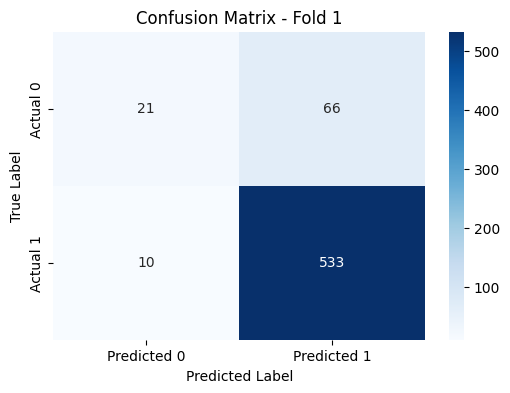

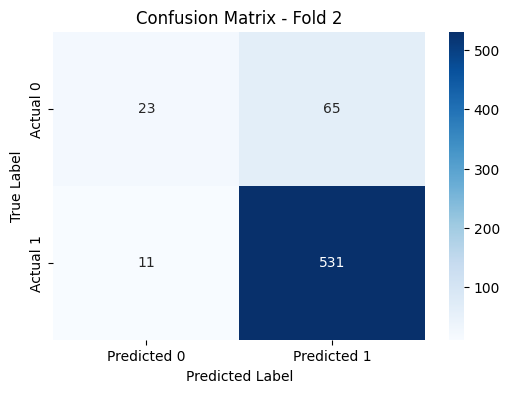

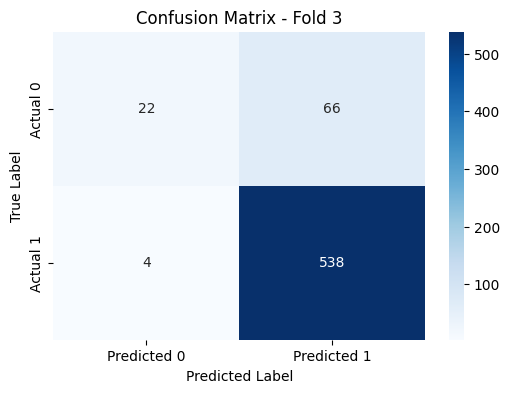

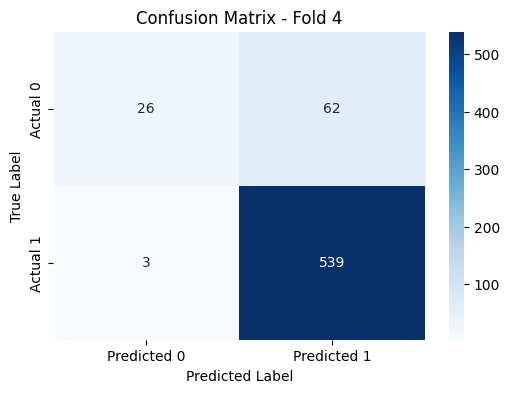

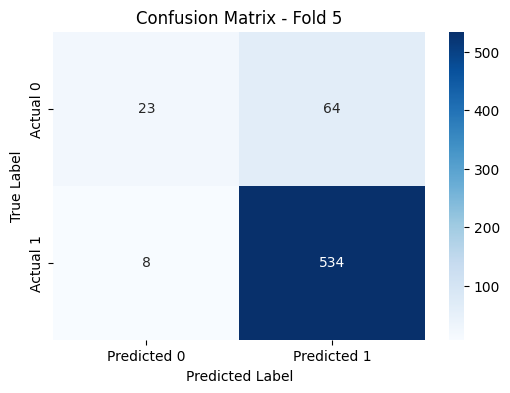

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n\U0001f4ca Confusion Matrices for Each Fold:")
for i in range(len(all_y_val)):
    cm = confusion_matrix(all_y_val[i], all_preds[i])
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - Fold {i+1}')
    plt.show()


🔢 ROC Curves for Each Fold:


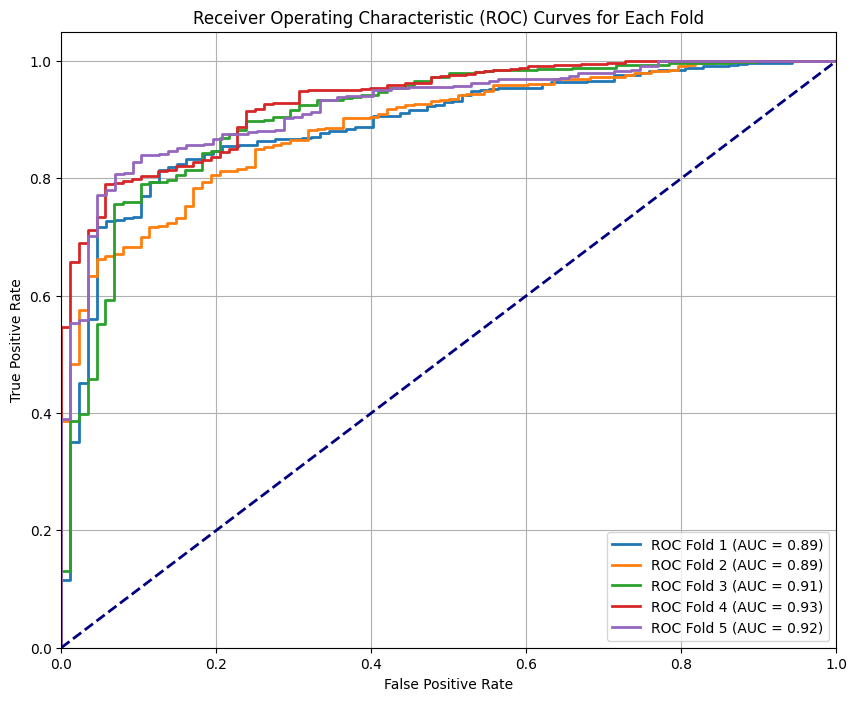

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("\n\U0001f522 ROC Curves for Each Fold:")
plt.figure(figsize=(10, 8))
for i in range(len(all_y_val)):
    fpr, tpr, _ = roc_curve(all_y_val[i], all_probs[i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Each Fold')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

# Reconstruct the previous set of features based on the code before the last modification
previous_demographics = ['VISITAGE', 'EDUC', 'BIRTHMO', 'BIRTHYR', 'HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'GENDER']
previous_family_history = ['MOMDEM', 'MOMAUTO', 'DADDEM', 'DADAUTO']
previous_cognitive_tests = [
    'ANIMALS', 'BOSTON',
    'TRAILA', 'TRAILARR', 'TRAILB', 'TRAILBRR',
    'FLUF'
]
previous_clinical_exams = ['GDS']
previous_functional_assessment = ['BILLS', 'TAXES', 'SHOPPING', 'GAMES', 'STOVE', 'MEALPREP', 'EVENTS', 'PAYATTN', 'TRAVEL']

previous_pure_clinical_features = [
    *previous_demographics,
    *previous_family_history,
    *previous_cognitive_tests,
    *previous_clinical_exams,
    *previous_functional_assessment
]

# Current user-provided features
current_user_features = [
    'EDUC', 'BIRTHMO', 'BIRTHYR', 'HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'GENDER',
    'MOMDEM', 'MOMAUTO', 'DADDEM', 'DADAUTO',
    'WORDIM', 'WORDDEL', 'LOGIMEM', 'MEMUNITS',
    'DIGIF', 'DIGIFLEN', 'DIGIB', 'DIGIBLEN',
    'ANIMALS', 'VEG', 'BOSTON',
    'TRAILA', 'TRAILB', 'WAIS', 'FLUF',
    'HXHYPER', 'HXSTROKE', 'HACHIN', 'GDS'
]

# Convert to sets for easy comparison
set_previous_features = set(previous_pure_clinical_features)
set_current_features = set(current_user_features)

# Find differences
removed_features = list(set_previous_features - set_current_features)
added_features = list(set_current_features - set_previous_features)
common_features = list(set_previous_features.intersection(set_current_features))

print("\n================ Feature Set Comparison ================")
print(f"\u2705 Features Common to Both Sets: {len(common_features)}")
if common_features:
    for feature in sorted(common_features):
        print(f"  - {feature}")
else:
    print("  None")

print(f"\n\u274C Features REMOVED from the previous set: {len(removed_features)}")
if removed_features:
    for feature in sorted(removed_features):
        print(f"  - {feature}")
else:
    print("  None")

print(f"\n\u2795 Features ADDED in the current set: {len(added_features)}")
if added_features:
    for feature in sorted(added_features):
        print(f"  - {feature}")
else:
    print("  None")

print("\nNote: The actual `final_features` used by the model might also exclude features not present in the DataFrame after filtering, or include dummy variables created from categorical features.")



================ Feature Set Comparison ================
✅ Features Common to Both Sets: 19
  - ANIMALS
  - BIRTHMO
  - BIRTHYR
  - BOSTON
  - DADAUTO
  - DADDEM
  - EDUC
  - FLUF
  - GDS
  - GENDER
  - HANDED
  - HISPANIC
  - MARISTAT
  - MOMAUTO
  - MOMDEM
  - PRIMLANG
  - RACE
  - TRAILA
  - TRAILB

❌ Features REMOVED from the previous set: 12
  - BILLS
  - EVENTS
  - GAMES
  - MEALPREP
  - PAYATTN
  - SHOPPING
  - STOVE
  - TAXES
  - TRAILARR
  - TRAILBRR
  - TRAVEL
  - VISITAGE

➕ Features ADDED in the current set: 13
  - DIGIB
  - DIGIBLEN
  - DIGIF
  - DIGIFLEN
  - HACHIN
  - HXHYPER
  - HXSTROKE
  - LOGIMEM
  - MEMUNITS
  - VEG
  - WAIS
  - WORDDEL
  - WORDIM

Note: The actual `final_features` used by the model might also exclude features not present in the DataFrame after filtering, or include dummy variables created from categorical features.


ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7dca54aabfa0>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

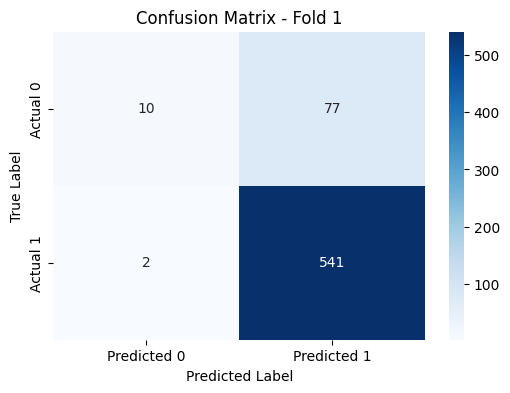

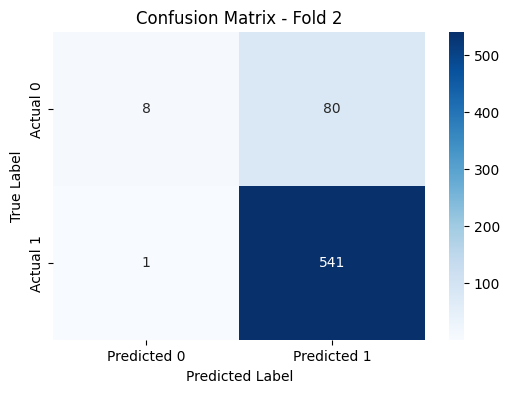

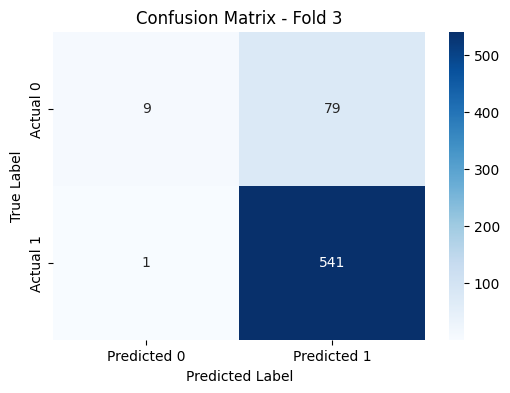

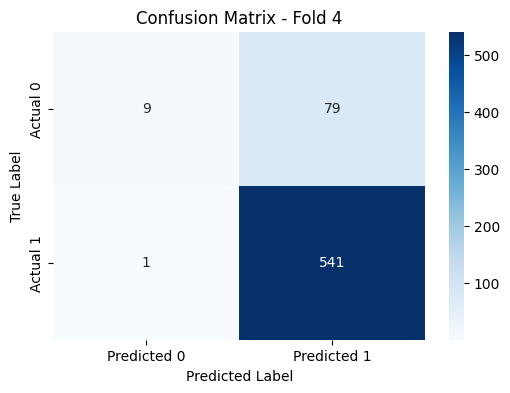

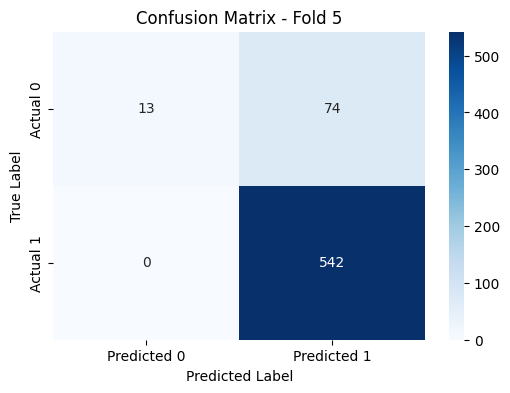

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n\uD83D\uDCCA Confusion Matrices for Each Fold:")
for i in range(len(all_y_val)):
    cm = confusion_matrix(all_y_val[i], all_preds[i])
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - Fold {i+1}')
    plt.show()

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7dca54aabfa0>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

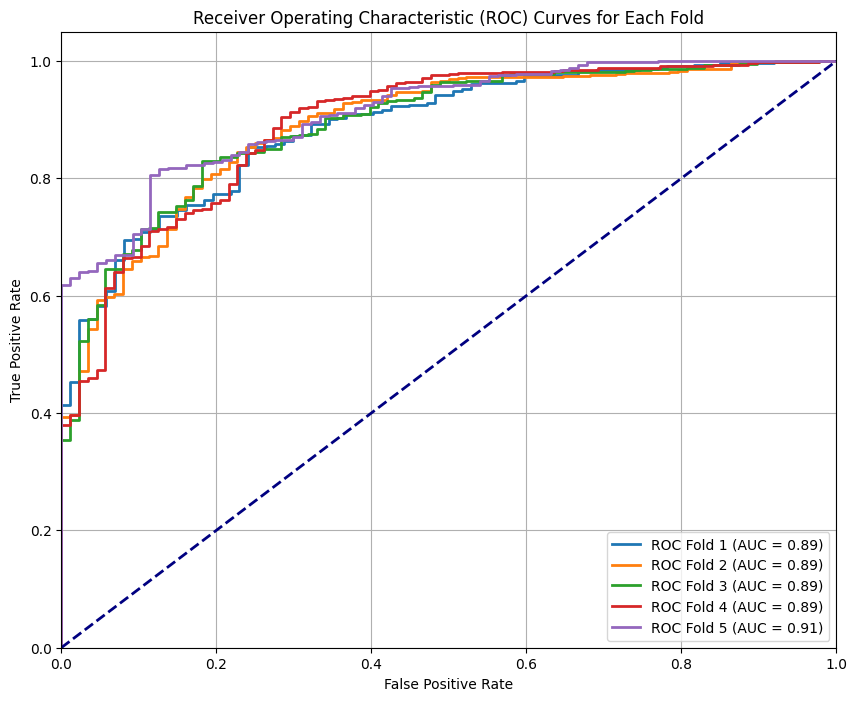

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("\n\uD83D\uDD22 ROC Curves for Each Fold:")
plt.figure(figsize=(10, 8))
for i in range(len(all_y_val)):
    fpr, tpr, _ = roc_curve(all_y_val[i], all_probs[i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Each Fold')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Feature Importance Analysis

To understand which attributes contribute most to the model's accuracy, we can examine the feature importances calculated by the Random Forest classifier. Higher importance scores indicate a greater influence on the model's predictions.

In [ ]:
# Calculate missing values percentage for each feature in the current X (user-provided features)
missing_percentages_current = X.isnull().sum() / len(X) * 100

# Filter features with more than 70% missing values
high_missing_features_current = missing_percentages_current[missing_percentages_current > 70].index.tolist()

print("\n================ Attributes with >70% Missing Values (Current Feature Set) ================")
if high_missing_features_current:
    for feature in high_missing_features_current:
        print(f"- {feature} ({missing_percentages_current[feature]:.2f}% missing)")
else:
    print("No attributes found with more than 70% missing values in the current feature set.")

# Display all attributes with their missing value percentages for the current feature set
missing_percentages_current_sorted = missing_percentages_current.sort_values(ascending=False)

print("\nMissing value percentages for all current attributes (sorted):")
for feature, percent in missing_percentages_current_sorted.items():
    print(f"- {feature}: {percent:.2f}%")


================ Attributes with >70% Missing Values (Current Feature Set) ================
- DIGIF (72.12% missing)
- DIGIFLEN (72.15% missing)
- DIGIB (72.34% missing)
- DIGIBLEN (72.37% missing)
- VEG (72.12% missing)
- WAIS (72.44% missing)
- HXHYPER (81.87% missing)
- HXSTROKE (81.87% missing)
- HACHIN (81.87% missing)

Missing value percentages for all current attributes (sorted):
- HXSTROKE: 81.87%
- HACHIN: 81.87%
- HXHYPER: 81.87%
- WAIS: 72.44%
- DIGIBLEN: 72.37%
- DIGIB: 72.34%
- DIGIFLEN: 72.15%
- VEG: 72.12%
- DIGIF: 72.12%
- FLUF: 29.98%
- MEMUNITS: 22.96%
- LOGIMEM: 22.36%
- GDS: 10.00%
- TRAILB: 7.88%
- TRAILA: 3.14%
- WORDDEL: 3.08%
- WORDIM: 2.92%
- BOSTON: 2.67%
- ANIMALS: 2.13%
- BIRTHMO: 0.76%
- BIRTHYR: 0.76%
- EDUC: 0.00%
- HISPANIC_1: 0.00%
- HISPANIC_9: 0.00%
- RACE_2: 0.00%
- RACE_3: 0.00%
- RACE_5: 0.00%
- RACE_50: 0.00%
- PRIMLANG_2: 0.00%
- PRIMLANG_8: 0.00%
- MARISTAT_2.0: 0.00%
- MARISTAT_3.0: 0.00%
- MARISTAT_5.0: 0.00%
- MARISTAT_9.0: 0.00%
- HANDED_2:


Top 15 Feature Importances:
     Feature  Importance
13     TAXES    0.099076
12     BILLS    0.093633
4    ANIMALS    0.081622
20    TRAVEL    0.078200
3    BIRTHYR    0.066213
18    EVENTS    0.061061
8     TRAILB    0.051706
14  SHOPPING    0.049742
0   VISITAGE    0.049561
11       GDS    0.049231
17  MEALPREP    0.046737
19   PAYATTN    0.043224
5     BOSTON    0.038482
15     GAMES    0.038076
6     TRAILA    0.030689


/tmp/ipykernel_654/872501415.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


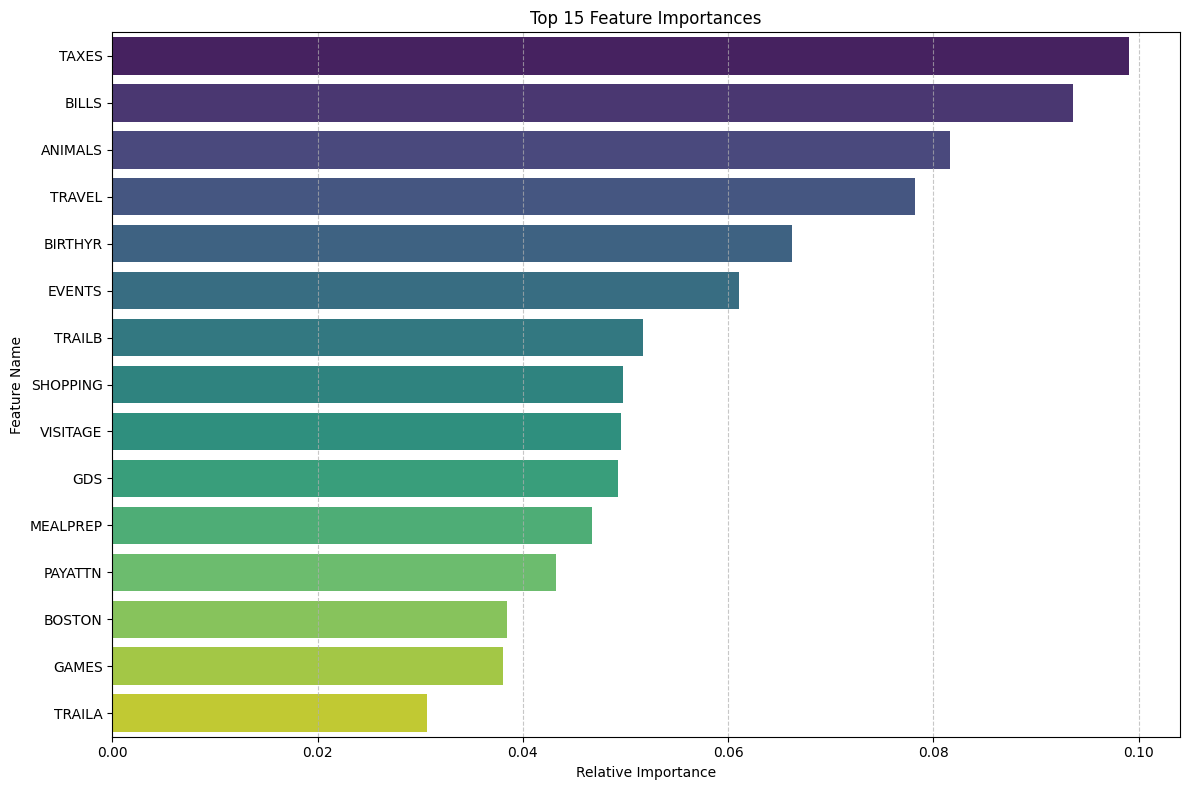

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': final_features,
    'Importance': feature_importances
})

# Sort features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display top N features (e.g., top 15)
print("\nTop 15 Feature Importances:")
print(feature_importance_df.head(15))

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

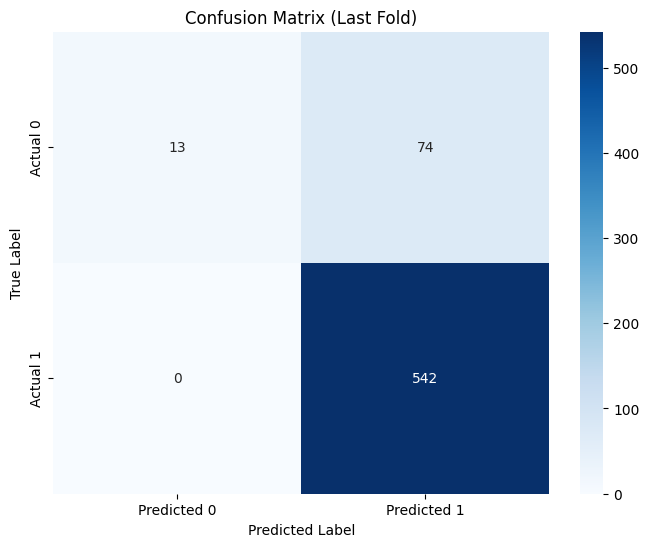

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate the confusion matrix for the last fold
cm = confusion_matrix(y_val, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Last Fold)')
plt.show()

### Check for Multicollinearity (Over-dependent Attributes)

Multicollinearity occurs when independent variables in a regression model are correlated. It can lead to unreliable and unstable estimates of regression coefficients. We can assess multicollinearity by looking at the correlation matrix of the features. High correlation values (close to 1 or -1) between features indicate potential multicollinearity.

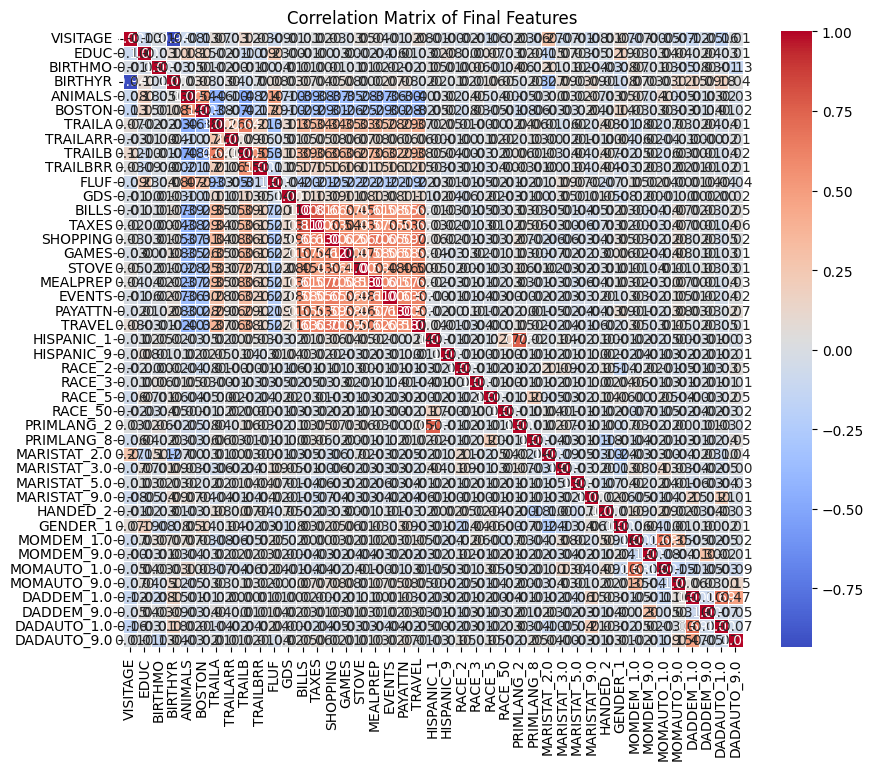

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = X[final_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Final Features')
plt.show()

In [ ]:
import numpy as np

# Recreate X before imputation to check original missing values
# This process mimics how X was created in the main script

# Demographics extracted from baseline clinician intake files
demographics = ['VISITAGE', 'EDUC', 'BIRTHMO', 'BIRTHYR', 'HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'GENDER']

# Family history
family_history = ['MOMDEM', 'MOMAUTO', 'DADDEM', 'DADAUTO']

# Standardized cognitive testing arrays frequently noted in clinical chart charts
cognitive_tests = [
    'WORDIM', 'WORDDEL', 'LOGIMEM', 'MEMUNITS',
    'DIGIF', 'DIGIFLEN', 'DIGIB', 'DIGIBLEN',
    'ANIMALS', 'VEG', 'BOSTON',
    'TRAILA', 'TRAILARR', 'TRAILB', 'TRAILBRR',
    'WAIS', 'FLUF'
]

# Overall functional status scores recorded during subjective clinical reviews
clinical_exams = ['ABRUPT', 'STEPWISE', 'SOMATIC', 'EMOT', 'HXHYPER', 'HXSTROKE', 'FOCLSYM', 'FOCLSIGN', 'HACHIN', 'GDS']

# Functional Assessment Scores
functional_assessment = ['BILLS', 'TAXES', 'SHOPPING', 'GAMES', 'STOVE', 'MEALPREP', 'EVENTS', 'PAYATTN', 'REMDATES', 'TRAVEL']

# Combine features into a strict clinical text scope (NO DNA, RNA, OR LAB BIOMARKERS)
pure_clinical_features = demographics + family_history + cognitive_tests + clinical_exams + functional_assessment

# Retain only the defined features that exist directly as columns in your CSV file
valid_features_before_dummies = [col for col in pure_clinical_features if col in df_filtered.columns]

X_pre_dummies = df_filtered[valid_features_before_dummies].copy()

categorical_cols_to_encode = ['HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'GENDER', 'MOMDEM', 'MOMAUTO', 'DADDEM', 'DADAUTO']
actual_categorical_cols = [col for col in categorical_cols_to_encode if col in X_pre_dummies.columns]
X_pre_imputation = pd.get_dummies(X_pre_dummies, columns=actual_categorical_cols, drop_first=True)

# Calculate missing values percentage for each feature
missing_percentages = X_pre_imputation.isnull().sum() / len(X_pre_imputation) * 100

# Filter features with more than 75% missing values
high_missing_features = missing_percentages[missing_percentages > 75].index.tolist()

if high_missing_features:
    print("\nAttributes with more than 75% missing values:")
    for feature in high_missing_features:
        print(f"- {feature} ({missing_percentages[feature]:.2f}% missing)")
else:
    print("\nNo attributes found with more than 75% missing values in the final feature set.")


Attributes with more than 75% missing values:
- ABRUPT (81.87% missing)
- STEPWISE (81.87% missing)
- SOMATIC (81.87% missing)
- EMOT (81.87% missing)
- HXHYPER (81.87% missing)
- HXSTROKE (81.87% missing)
- FOCLSYM (81.87% missing)
- FOCLSIGN (81.87% missing)
- HACHIN (81.87% missing)


In [ ]:
# Display all attributes with their missing value percentages
# sorted from highest to lowest missing percentage
missing_percentages_sorted = missing_percentages.sort_values(ascending=False)

print("\nMissing value percentages for all attributes (sorted):")
for feature, percent in missing_percentages_sorted.items():
    print(f"- {feature}: {percent:.2f}%")


Missing value percentages for all attributes (sorted):
- EMOT: 81.87%
- HXHYPER: 81.87%
- HXSTROKE: 81.87%
- FOCLSYM: 81.87%
- FOCLSIGN: 81.87%
- STEPWISE: 81.87%
- HACHIN: 81.87%
- SOMATIC: 81.87%
- ABRUPT: 81.87%
- WAIS: 72.44%
- DIGIBLEN: 72.37%
- DIGIB: 72.34%
- DIGIFLEN: 72.15%
- DIGIF: 72.12%
- VEG: 72.12%
- FLUF: 29.98%
- MEMUNITS: 22.96%
- LOGIMEM: 22.36%
- GDS: 10.00%
- TRAILBRR: 7.88%
- TRAILB: 7.88%
- TRAILARR: 3.18%
- TRAILA: 3.14%
- WORDDEL: 3.08%
- WORDIM: 2.92%
- BOSTON: 2.67%
- ANIMALS: 2.13%
- TAXES: 1.30%
- BILLS: 1.30%
- GAMES: 1.24%
- SHOPPING: 1.24%
- PAYATTN: 1.24%
- STOVE: 1.21%
- MEALPREP: 1.21%
- EVENTS: 1.21%
- TRAVEL: 1.21%
- REMDATES: 1.17%
- BIRTHYR: 0.76%
- BIRTHMO: 0.76%
- VISITAGE: 0.00%
- EDUC: 0.00%
- HISPANIC_1: 0.00%
- HISPANIC_9: 0.00%
- RACE_2: 0.00%
- RACE_3: 0.00%
- RACE_5: 0.00%
- RACE_50: 0.00%
- PRIMLANG_2: 0.00%
- PRIMLANG_8: 0.00%
- MARISTAT_2.0: 0.00%
- MARISTAT_3.0: 0.00%
- MARISTAT_5.0: 0.00%
- MARISTAT_9.0: 0.00%
- HANDED_2: 0.00%
- GEN